In [78]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
from scipy.stats import spearmanr
from sklearn.inspection import permutation_importance



def load_teams_data():
    try:
        teams = pd.read_csv('dataset/teams.csv')
        
        return teams
        
    except FileNotFoundError:
        print("Error: teams.csv file not found in dataset folder!")
        return None
    
    except Exception as e:
        print(f"Error loading data: {e}")
        return None

def load_teams_post_data():
    try:
        teams_post = pd.read_csv('dataset/teams_post.csv')
        
        return teams_post
        
    except FileNotFoundError:
        print("Error: teams_post.csv file not found in dataset folder!")
        return None
    
    except Exception as e:
        print(f"Error loading data: {e}")
        return None
    
def load_series_data():
    try:
        series = pd.read_csv('dataset/series_post.csv')
        
        return series
        
    except FileNotFoundError:
        print("Error: series.csv file not found in dataset folder!")
        return None
    
    except Exception as e:
        print(f"Error loading data: {e}")
        return None    

In [79]:
teams_data = load_teams_data()
teams_post_data = load_teams_post_data()
series_data = load_series_data()

In [80]:
clean_data = teams_data[['tmID', 'confID', 'year', 'rank']]
team_conf_map = teams_data.groupby('tmID')['confID'].first().to_dict()

In [81]:
def evaluate_ranking_accuracy(test, predicted_rankings):
    # Merge the predicted rankings with the actual rankings for year 10
    actual_rankings = test[['year', 'tmID', 'rank']]  # Actual rankings for year 10
    predictions = predicted_rankings[['year', 'tmID', 'predicted_rank']]  # Predicted rankings for year 10

    # Merge them on 'tmID' and 'year'
    rankings_comparison = pd.merge(actual_rankings, predictions, on=['year', 'tmID'])

    # Calculate Mean Absolute Error (MAE) for rankings
    mae = mean_absolute_error(rankings_comparison['rank'], rankings_comparison['predicted_rank'])
    print(f"Mean Absolute Error (MAE) for rankings: {mae:.4f}")

    # Calculate Spearman's Rank Correlation
    spearman_corr, _ = spearmanr(rankings_comparison['rank'], rankings_comparison['predicted_rank'])
    print(f"Spearman's Rank Correlation for rankings: {spearman_corr:.4f}")

In [84]:
def random_forest_predict_rankings_default_features():
    team_conf_df = pd.DataFrame(list(team_conf_map.items()), columns=['tmID', 'confID'])
    rank_by_team = clean_data.groupby('tmID')['rank'].mean().reset_index()
    feature_cols = ["o_fgm", "o_fga", "o_ftm", "o_fta", "o_3pm", "o_3pa",       "o_oreb", "o_dreb", "o_reb", 
                    "o_asts", "o_pf", "o_stl", "o_to", "o_blk", "o_pts", "d_fgm", "d_fga", "d_ftm", "d_fta", "d_3pm", 
                    "d_3pa", "d_oreb", "d_dreb", "d_reb", "d_asts", "d_pf", "d_stl", "d_to", "d_blk", "d_pts", "won", "lost", "GP", "homeW", "homeL", "awayW", "awayL", "confW", "confL"]
    X = teams_data[feature_cols]
    y = teams_data['rank']

    train = teams_data[teams_data['year'] < 10]
    test = teams_data[teams_data['year'] == 10]

    x_train, y_train = train[feature_cols], train['rank']
    x_test, y_test = test[feature_cols], test['rank']

    model = RandomForestRegressor(n_estimators=300, random_state=42)
    model.fit(x_train, y_train)

    y_pred = model.predict(x_test)

    test['predicted_rank'] = y_pred

    predicted_rankings = test[['year', 'tmID', 'confID', 'predicted_rank']].sort_values(by=['confID', 'predicted_rank'])
    print(f"\nPredicted Rankings for Year 10:")
    print(predicted_rankings.to_string(index=False))
    print("\nPredicted Rankings by Conference:")
    conf_rankings = predicted_rankings.groupby('confID').apply(lambda x: x[['tmID', 'predicted_rank']].reset_index(drop=True))
    print(conf_rankings.to_string(index=False))
    evaluate_ranking_accuracy(test, predicted_rankings)

    importances = model.feature_importances_
    # Create a DataFrame to pair feature names with their importance score
    feature_importance_df = pd.DataFrame({
        'feature': feature_cols,
        'importance': importances
    })

    # Sort the features by their importance
    feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)

    # Plot the feature importance
    plt.figure(figsize=(10, 6))
    plt.barh(feature_importance_df['feature'], feature_importance_df['importance'])
    plt.xlabel('Importance')
    plt.title('Feature Importance')
    plt.show()

    result = permutation_importance(model, x_test, y_test, n_repeats=10, random_state=42)

    # Create a DataFrame with the permutation importance results
    perm_importance_df = pd.DataFrame({
        'feature': feature_cols,
        'importance': result.importances_mean
    })

    # Sort the features by their importance
    perm_importance_df = perm_importance_df.sort_values(by='importance', ascending=False)

    # Plot the permutation importance
    plt.figure(figsize=(10, 6))
    plt.barh(perm_importance_df['feature'], perm_importance_df['importance'])
    plt.xlabel('Importance')
    plt.title('Permutation Feature Importance')
    plt.show()

    # Calculate correlation of each feature with the target variable (rank)
    correlation = teams_data[feature_cols + ['rank']].corr()['rank'].drop('rank')

    # Sort the correlation values
    correlation_sorted = correlation.sort_values(ascending=False)

    print("Correlation with rank:")
    print(correlation_sorted)



Predicted Rankings for Year 10:
 year tmID confID  predicted_rank
   10  IND     EA        1.470000
   10  DET     EA        3.953333
   10  ATL     EA        4.130000
   10  WAS     EA        5.226667
   10  CHI     EA        5.250000
   10  NYL     EA        5.250000
   10  CON     EA        5.633333
   10  PHO     WE        1.353333
   10  SEA     WE        2.316667
   10  LAS     WE        3.296667
   10  SAS     WE        5.133333
   10  MIN     WE        5.610000
   10  SAC     WE        5.930000

Predicted Rankings by Conference:
tmID  predicted_rank
 IND        1.470000
 DET        3.953333
 ATL        4.130000
 WAS        5.226667
 CHI        5.250000
 NYL        5.250000
 CON        5.633333
 PHO        1.353333
 SEA        2.316667
 LAS        3.296667
 SAS        5.133333
 MIN        5.610000
 SAC        5.930000
Mean Absolute Error (MAE) for rankings: 0.7636
Spearman's Rank Correlation for rankings: 0.9251


/tmp/ipykernel_7138/4107752604.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['predicted_rank'] = y_pred
/tmp/ipykernel_7138/4107752604.py:27: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  conf_rankings = predicted_rankings.groupby('confID').apply(lambda x: x[['tmID', 'predicted_rank']].reset_index(drop=True))


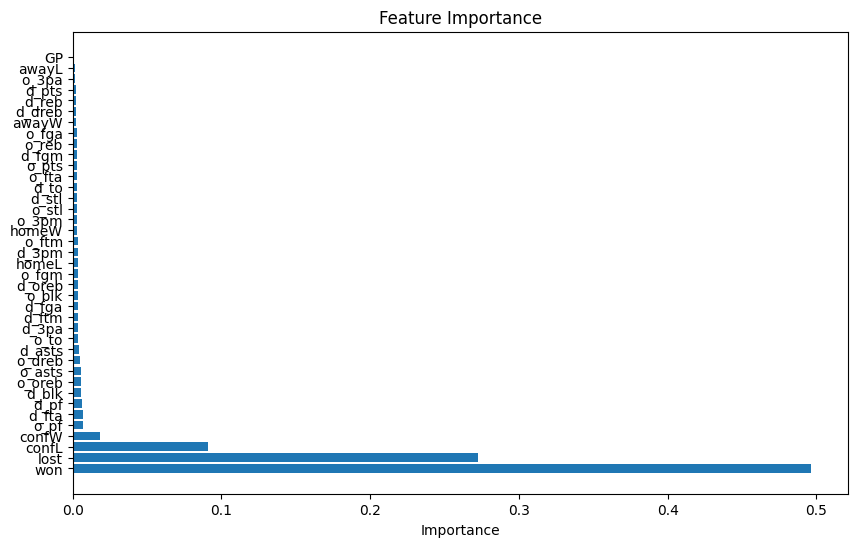

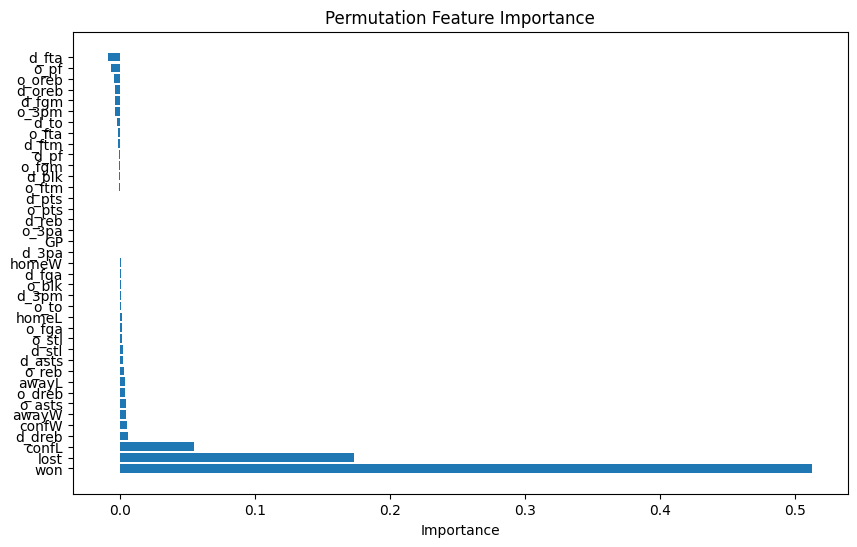

Correlation with rank:
lost      0.869440
confL     0.861650
homeL     0.781505
awayL     0.742283
d_blk     0.266284
d_asts    0.205236
d_ftm     0.166292
d_fta     0.147071
o_pf      0.130553
d_stl     0.117595
d_pts     0.111783
d_fgm     0.097489
d_dreb    0.089654
o_to      0.077820
d_reb     0.065357
d_oreb   -0.014061
o_3pa    -0.052629
o_oreb   -0.053003
d_3pm    -0.054407
d_to     -0.070871
o_3pm    -0.117247
o_fga    -0.128011
GP       -0.142208
o_fta    -0.163606
d_pf     -0.165619
d_fga    -0.172235
o_stl    -0.193651
d_3pa    -0.221364
o_ftm    -0.230563
o_blk    -0.248392
o_reb    -0.325513
o_pts    -0.331363
o_fgm    -0.339845
o_dreb   -0.385275
o_asts   -0.449623
awayW    -0.775317
homeW    -0.797081
confW    -0.851473
won      -0.896448
Name: rank, dtype: float64


In [85]:
random_forest_predict_rankings_default_features()